# Load Harmonized Landsat Sentinel-2 (HLS) data from the Planetary Computer STAC catalog

This notebook shows an example how to load Harmonized Landsat Sentinel-2 (HLS) data from the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/).

## Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

Now, we first import everything we need:

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from xcube.core.store import new_data_store, get_data_store_params_schema
from xcube_resampling.utils import reproject_bbox

In [2]:
xr.set_options(display_expand_attrs=False)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/):

- **`stac-pc-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-pc`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal analysis-ready data cubes 
In the following, we will first demonstrate how to use the `stac-pc-ardc` store. To initialize the data store instance, no parameters are needed as indecated in the following cell. 

In [3]:
%%time
store_params = get_data_store_params_schema("stac-pc-ardc")
store_params

CPU times: user 228 ms, sys: 49.8 ms, total: 277 ms
Wall time: 277 ms


In [4]:
%%time
store = new_data_store("stac-pc-ardc")

CPU times: user 14.4 ms, sys: 4.94 ms, total: 19.3 ms
Wall time: 128 ms


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [5]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 34 μs, sys: 3 μs, total: 37 μs
Wall time: 41.2 μs


['sentinel-2-l2a',
 'sentinel-3-synergy-syn-l2-netcdf',
 'sentinel-3-slstr-lst-l2-netcdf',
 'hls2-l30',
 'hls2-s30']

Below, the parameters for the `open_data` method can be viewed for a specific data ID.

In [6]:
%%time
open_params = store.get_open_data_params_schema("hls2-l30")
open_params

CPU times: user 69 μs, sys: 6 μs, total: 75 μs
Wall time: 78.9 μs


First we request the Landsat datacube, where we set the bounding box to cover the greater Hamburg area and the time range to July 2024.

In [7]:
%%time
ds_landsat = store.open_data(
    data_id="hls2-l30",
    bbox=[9.7, 53.3, 10.3, 53.8],
    time_range=["2024-07-01", "2024-08-01"],
    spatial_res=30 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["B02", "B03", "B04"],
)
ds_landsat

CPU times: user 3.52 s, sys: 175 ms, total: 3.69 s
Wall time: 5.55 s


<xarray.Dataset> Size: 347MB
Dimensions:      (time: 7, lon: 2227, lat: 1856)
Coordinates:
  * time         (time) datetime64[ns] 56B 2024-07-04T10:19:57.430563 ... 202...
  * lon          (lon) float64 18kB 9.7 9.7 9.701 9.701 ... 10.3 10.3 10.3 10.3
  * lat          (lat) float64 15kB 53.8 53.8 53.8 53.8 ... 53.3 53.3 53.3 53.3
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, lat, lon) float32 116MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    B03          (time, lat, lon) float32 116MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    B04          (time, lat, lon) float32 116MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
Attributes: (4)

We can request the Sentinel-2 data cube for the same opening parameters.

In [8]:
%%time
ds_sen2 = store.open_data(
    data_id="hls2-s30",
    bbox=[9.7, 53.3, 10.3, 53.8],
    time_range=["2024-07-01", "2024-08-01"],
    spatial_res=30 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["B02", "B03", "B04"],
)
ds_sen2

CPU times: user 3.67 s, sys: 115 ms, total: 3.79 s
Wall time: 7.42 s


<xarray.Dataset> Size: 546MB
Dimensions:      (time: 11, lon: 2227, lat: 1856)
Coordinates:
  * time         (time) datetime64[ns] 88B 2024-07-07T10:36:04.551300 ... 202...
  * lon          (lon) float64 18kB 9.7 9.7 9.701 9.701 ... 10.3 10.3 10.3 10.3
  * lat          (lat) float64 15kB 53.8 53.8 53.8 53.8 ... 53.3 53.3 53.3 53.3
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, lat, lon) float32 182MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    B03          (time, lat, lon) float32 182MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    B04          (time, lat, lon) float32 182MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
Attributes: (4)

We can plot the B04 (red) band from both datacubes for the same date as comparison.

CPU times: user 6.78 s, sys: 1.27 s, total: 8.05 s
Wall time: 10 s


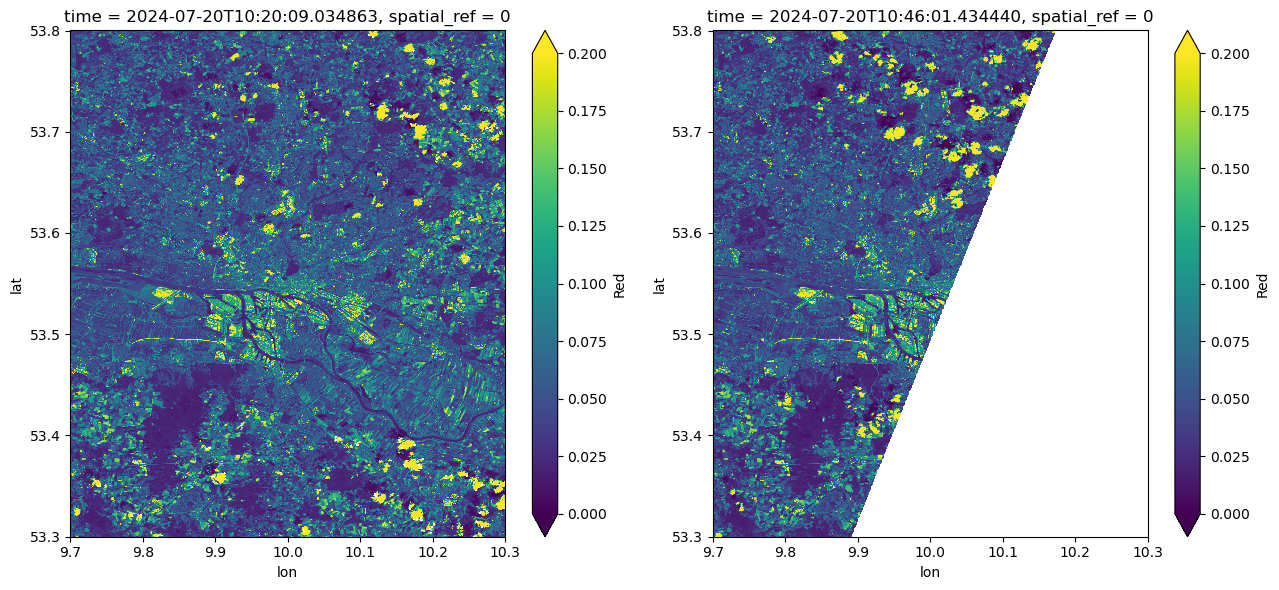

In [9]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ds_landsat.B04.sel(time="2024-07-20").plot(ax=ax[0], vmin=0., vmax=0.2)
ds_sen2.B04.sel(time="2024-07-20").plot(ax=ax[1], vmin=0., vmax=0.2)
plt.tight_layout()

The data can also be presented in a difference CRS as shown below.

In [10]:
bbox = [9.7, 53.3, 10.3, 53.8]
crs_target = "EPSG:32632"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_target)

In [11]:
%%time
ds_landsat = store.open_data(
    data_id="hls2-l30",
    bbox=bbox_utm,
    time_range=["2024-07-01", "2024-08-01"],
    spatial_res=30,  # meter
    crs=crs_target,
    asset_names=["B02", "B03", "B04"],
)
ds_landsat

CPU times: user 433 ms, sys: 4.82 ms, total: 438 ms
Wall time: 493 ms


<xarray.Dataset> Size: 213MB
Dimensions:      (time: 7, y: 1873, x: 1352)
Coordinates:
  * time         (time) datetime64[ns] 56B 2024-07-04T10:19:57.430563 ... 202...
  * y            (y) float64 15kB 5.962e+06 5.962e+06 ... 5.906e+06 5.906e+06
  * x            (x) float64 11kB 5.461e+05 5.461e+05 ... 5.866e+05 5.866e+05
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, y, x) float32 71MB dask.array<chunksize=(1, 783, 511), meta=np.ndarray>
    B03          (time, y, x) float32 71MB dask.array<chunksize=(1, 783, 511), meta=np.ndarray>
    B04          (time, y, x) float32 71MB dask.array<chunksize=(1, 783, 511), meta=np.ndarray>
Attributes: (4)

In [12]:
%%time
ds_sen2 = store.open_data(
    data_id="hls2-s30",
    bbox=bbox_utm,
    time_range=["2024-07-01", "2024-08-01"],
    spatial_res=30,  # meter
    crs=crs_target,
    asset_names=["B02", "B03", "B04"],
)
ds_sen2

CPU times: user 1.26 s, sys: 20.8 ms, total: 1.28 s
Wall time: 3.3 s


<xarray.Dataset> Size: 517MB
Dimensions:      (time: 17, y: 1873, x: 1352)
Coordinates:
  * time         (time) datetime64[ns] 136B 2024-07-04T10:26:09.009570 ... 20...
  * y            (y) float64 15kB 5.962e+06 5.962e+06 ... 5.906e+06 5.906e+06
  * x            (x) float64 11kB 5.461e+05 5.461e+05 ... 5.866e+05 5.866e+05
    spatial_ref  int64 8B 0
Data variables:
    B02          (time, y, x) float32 172MB dask.array<chunksize=(1, 783, 511), meta=np.ndarray>
    B03          (time, y, x) float32 172MB dask.array<chunksize=(1, 783, 511), meta=np.ndarray>
    B04          (time, y, x) float32 172MB dask.array<chunksize=(1, 783, 511), meta=np.ndarray>
Attributes: (4)

Again, we can plot the B04 (red) band from both datacubes for the same date as comparison.

CPU times: user 2.61 s, sys: 573 ms, total: 3.19 s
Wall time: 8.92 s


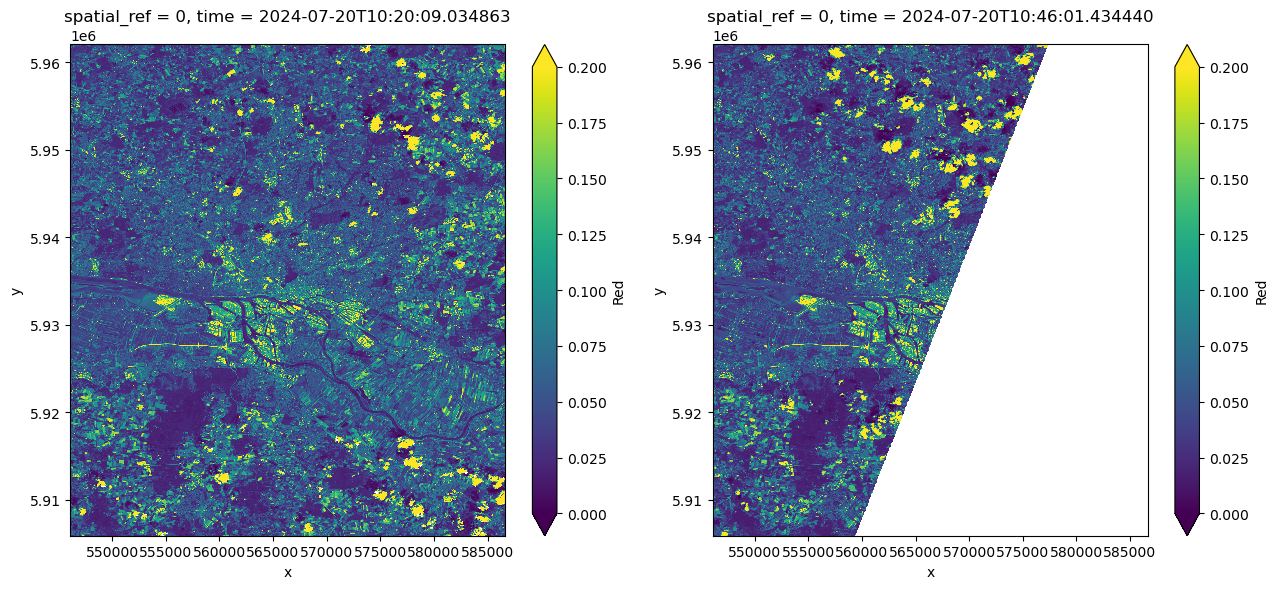

In [13]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ds_landsat.B04.sel(time="2024-07-20").plot(ax=ax[0], vmin=0., vmax=0.2)
ds_sen2.B04.sel(time="2024-07-20").plot(ax=ax[1], vmin=0., vmax=0.2)
plt.tight_layout()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [14]:
%%time
store = new_data_store("stac-pc")

CPU times: user 36.2 ms, sys: 3.44 ms, total: 39.7 ms
Wall time: 362 ms


In the next step, we can search for items using search parameters. The following code shows which search parameters are available.

In [15]:
%%time
search_params = store.get_search_params_schema()
search_params

CPU times: user 41 μs, sys: 3 μs, total: 44 μs
Wall time: 49.4 μs


 Next, we will search for tiles of Sentinel-2 tiles from the HLS. The data IDs point to a [STAC item's JSON](https://github.com/radiantearth/stac-spec/blob/master/item-spec/item-spec.md) and are specified by the segment of the URL that follows the catalog's URL.

In [16]:
%%time
descriptors = list(
    store.search_data(
        collections=["hls2-s30"],
        bbox=[9, 47, 10, 48],
        time_range=["2024-07-19", "2024-07-21"],
    )
)
[d.to_dict() for d in descriptors]

CPU times: user 192 ms, sys: 6.1 ms, total: 198 ms
Wall time: 3.01 s


[{'data_id': 'collections/hls2-s30/items/HLS.S30.T32TMT.2024201T102021.v2.0',
  'data_type': 'dataset',
  'bbox': [7.763528, 46.859022, 9.13047, 47.853628],
  'time_range': ('2024-07-19T10:27:49.750680Z',
   '2024-07-19T10:27:49.750680Z')},
 {'data_id': 'collections/hls2-s30/items/HLS.S30.T32TNT.2024201T102021.v2.0',
  'data_type': 'dataset',
  'bbox': [8.999733, 46.85664, 10.467277, 47.853702],
  'time_range': ('2024-07-19T10:27:45.978440Z',
   '2024-07-19T10:27:45.978440Z')},
 {'data_id': 'collections/hls2-s30/items/HLS.S30.T32UMU.2024201T102021.v2.0',
  'data_type': 'dataset',
  'bbox': [8.090185, 47.76156, 9.132783, 48.752937],
  'time_range': ('2024-07-19T10:27:34.961300Z',
   '2024-07-19T10:27:34.961300Z')},
 {'data_id': 'collections/hls2-s30/items/HLS.S30.T32UNU.2024201T102021.v2.0',
  'data_type': 'dataset',
  'bbox': [8.999728, 47.755819, 10.493269, 48.753013],
  'time_range': ('2024-07-19T10:27:31.605970Z',
   '2024-07-19T10:27:31.605970Z')}]

In the next step, we can open the data for each data ID. The following code shows which parameters are available for opening the data.

In [17]:
%%time
open_params = store.get_open_data_params_schema(data_id="collections/hls2-s30/items/HLS.S30.T32TNT.2024201T102021.v2.0")
open_params

CPU times: user 74 μs, sys: 6 μs, total: 80 μs
Wall time: 83.7 μs


We can lazily load the corresponding data as shown below.

In [18]:
%%time
ds = store.open_data("collections/hls2-s30/items/HLS.S30.T32TNT.2024201T102021.v2.0")
ds

CPU times: user 276 ms, sys: 12 ms, total: 288 ms
Wall time: 1.64 s


<xarray.Dataset> Size: 697MB
Dimensions:      (x: 3660, y: 3660)
Coordinates:
  * x            (x) float64 29kB 5e+05 5e+05 5.001e+05 ... 6.097e+05 6.098e+05
  * y            (y) float64 29kB 5.3e+06 5.3e+06 5.3e+06 ... 5.19e+06 5.19e+06
    spatial_ref  int64 8B 0
Data variables: (12/13)
    B01          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B02          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B03          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B04          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B05          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B06          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    ...           ...
    B08          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B8A          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B09          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B10          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B11          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    B12          (y, x) float32 54MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (3)

We plot one data array as an example below.

CPU times: user 1.19 s, sys: 288 ms, total: 1.48 s
Wall time: 4.25 s


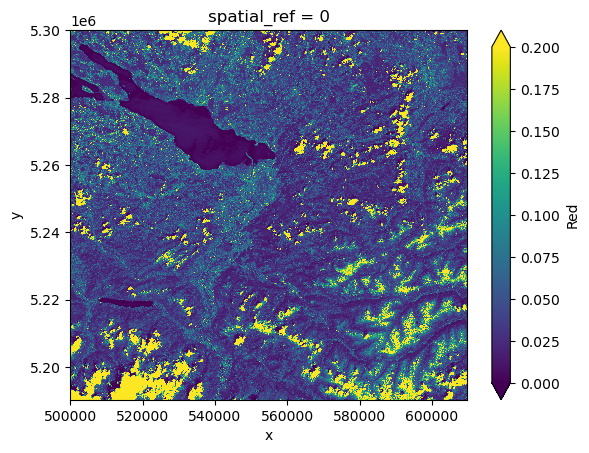

In [19]:
%%time
ds.B04[::3, ::3].plot(vmin=0.0, vmax=0.2)